# Notebook for LSTM 
Most recent update (02.04.2024): construct a univariate LSTM to implement the lagged approach.

In [128]:
#importing functions and  packages 
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from helpers import fix_datetime_format, create_sliding_windows
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, InputLayer, Input, Flatten,  RepeatVector, TimeDistributed
from tensorflow.keras import Input



In [85]:
random_state = 42

## Data Import & Preprocessing

In [86]:
# Data import
data = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})

#remove 2025 data
data = data[data["full_datetime"] < "2025-01-01-01"]
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days
70123,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0,2024-12-31-20
70124,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0,2024-12-31-21
70125,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0,2024-12-31-22
70126,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0,2024-12-31-23
70127,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0,2024-12-31-24


In [87]:
# fix correct_days variable and turn into index
# Apply the fix
data["correct_days"] = data["correct_days"].apply(fix_datetime_format)

#set index
data.set_index('correct_days', inplace=True)
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor
correct_days,,,,,,,,,,,,,
2024-12-31 20:00:00,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0
2024-12-31 21:00:00,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0
2024-12-31 22:00:00,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0
2024-12-31 23:00:00,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0
2025-01-01 00:00:00,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0


We first want to analyze the data using a lagged approach. Hence, all variables apart from volume need to be dropped.

In [88]:
X = pd.DataFrame(data["volume"])#we need the shape to be (70128, 1), not (70128, )
X.shape
X.head()

#check type of target variable 
type(X.volume[0])


#Separate the training from the test data before scaling so only the train data is scaled.
train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
test_data = X["2024-12-25 00:00:00":"2024-12-31 23:00:00"]

# convert to float as is recommended 
train_data_2 = train_data.values #turn into ndarray
train_data_2 = train_data_2.astype("float32")
train_data = pd.DataFrame(data=train_data_2, index = train_data.index.values, columns=["volume"])


test_data_2 = test_data.values
test_data_2 = test_data_2.astype("float32")
test_data = pd.DataFrame(data=test_data_2, index = test_data.index.values, columns=["volume"])

train_data.tail()
test_data.head()

/var/folders/xk/v_s45nd9057cbzm0wb_2259m0000gn/T/ipykernel_88269/1443158175.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(X.volume[0])


,volume
2024-12-25 00:00:00,952750.0
2024-12-25 01:00:00,858500.0
2024-12-25 02:00:00,753251.0
2024-12-25 03:00:00,503250.0
2024-12-25 04:00:00,434000.0


In [89]:
test_data.head()

,volume
2024-12-25 00:00:00,952750.0
2024-12-25 01:00:00,858500.0
2024-12-25 02:00:00,753251.0
2024-12-25 03:00:00,503250.0
2024-12-25 04:00:00,434000.0


Text(0.5, 1.0, 'Training Data')

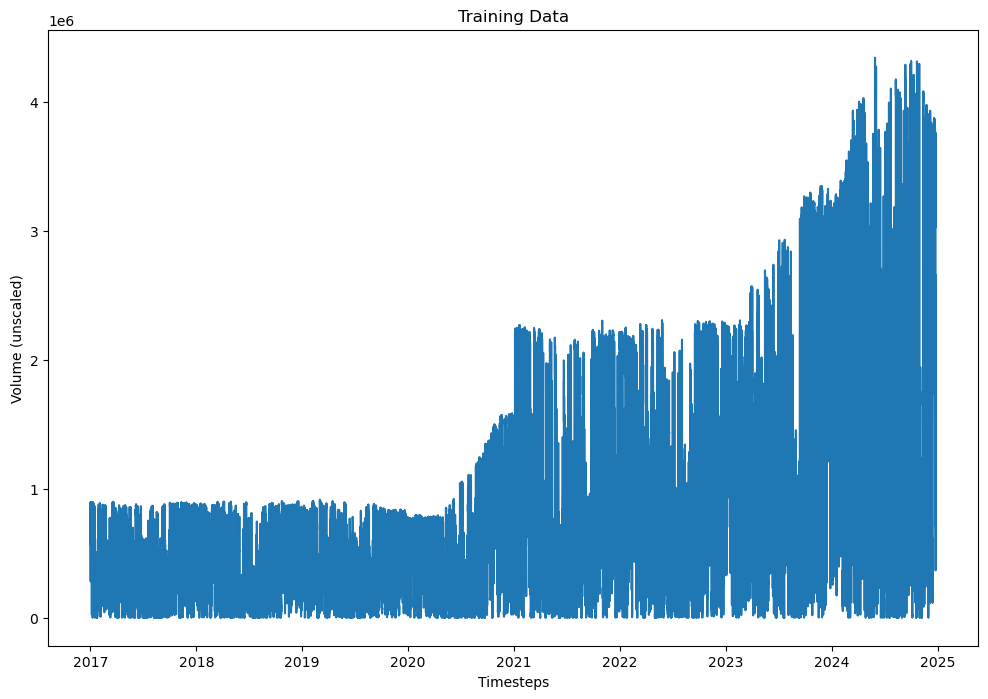

In [90]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(train_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Training Data")

Text(0.5, 1.0, 'Test Data')

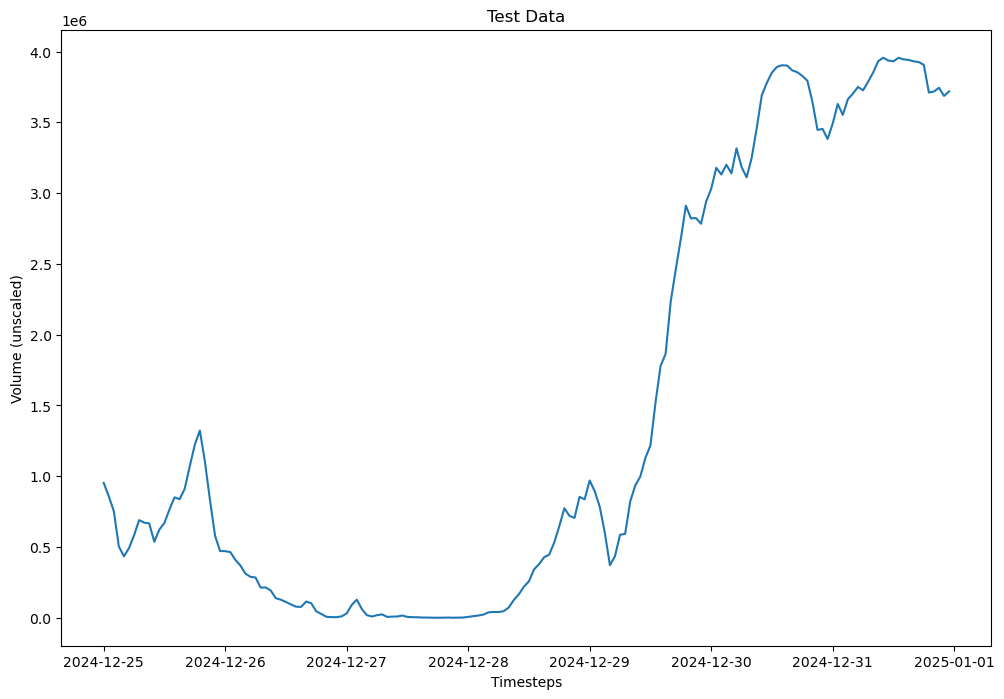

In [91]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(test_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Test Data")

Normalize the data, because LSTM is sensitive to the scale of the input data.

In [92]:
object = StandardScaler()

#standardization
train_data = object.fit_transform(train_data)

print(train_data[:5])


[[0.0578516 ]
 [0.07004705]
 [0.05666038]
 [0.07718842]
 [0.08135473]]


## Create 3D-dataset

In [93]:
X_train, y_train = create_sliding_windows(train_data)
X_test, y_test = create_sliding_windows(test_data, x_len=20, y_len=2)

## Model Creation 

In [134]:
# extract parameters for model definition
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
n_outputs = y_train.shape[1]
n_batch = X_train.shape[0]

# create and fit LSTM 
model = Sequential()
model.add(InputLayer(batch_shape=X_train.shape))
model.add(LSTM(units=4, # apparently this is the "hidden neurons" (hyperparameter). No idea if this is correct
          stateful=True))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")
model.fit(X_train, y_train[:, 0], epochs=10, batch_size= 1, # how many samples the models sees before updating the weights 
          verbose=2)

Epoch 1/10
164/164 - 12s - 73ms/step - loss: 0.4187
Epoch 2/10
164/164 - 10s - 63ms/step - loss: 0.3239
Epoch 3/10
164/164 - 11s - 64ms/step - loss: 0.2773
Epoch 4/10
164/164 - 11s - 65ms/step - loss: 0.2411
Epoch 5/10
164/164 - 10s - 62ms/step - loss: 0.2109
Epoch 6/10
164/164 - 10s - 62ms/step - loss: 0.1848
Epoch 7/10
164/164 - 11s - 64ms/step - loss: 0.1626
Epoch 8/10
164/164 - 10s - 63ms/step - loss: 0.1432
Epoch 9/10
164/164 - 10s - 62ms/step - loss: 0.1285
Epoch 10/10
164/164 - 11s - 68ms/step - loss: 0.1120


## Predictions & Evaluation

In [137]:
# make predictions
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

#calculate MSE
train_score = np.sqrt(mean_squared_error(y_train[:, 0], train_preds[:, 0]))
print(train_score)
test_score = np.sqrt(mean_squared_error(y_test[:, 0], test_preds[:, 0]))
print(test_score)



ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 32 and 164 for '{{node sequential_17_1/lstm_17_1/lstm_cell_1/add}} = AddV2[T=DT_FLOAT](sequential_17_1/lstm_17_1/lstm_cell_1/MatMul, sequential_17_1/lstm_17_1/lstm_cell_1/MatMul_1)' with input shapes: [32,16], [164,16].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 1), dtype=float32)
  • states=('tf.Tensor(shape=(164, 4), dtype=float32)', 'tf.Tensor(shape=(164, 4), dtype=float32)')
  • training=False

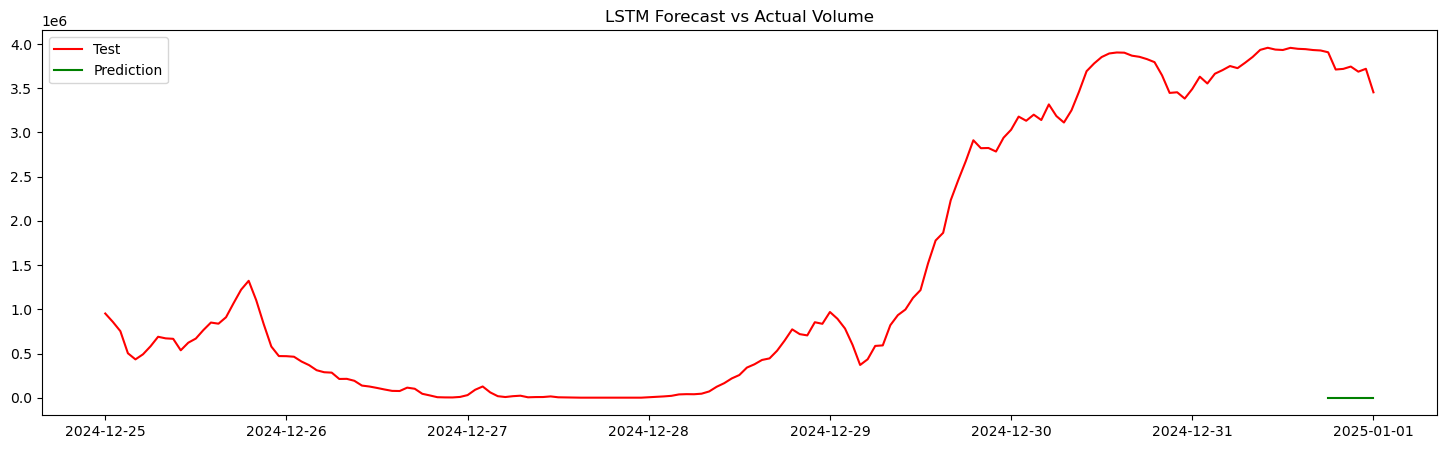

In [122]:
# get data with time indexes agai
train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
test_data = X["2024-12-25 00:00:00":]



test_preds = pd.DataFrame(data = test_preds, index=test_data.index.values[-7:], columns=["volume"])


# Plot predictions
plt.figure(figsize=(18,5))
plt.plot(test_data, label="Test", color="red")
plt.plot(test_preds, label="Prediction", color="green")
plt.legend()
plt.title("LSTM Forecast vs Actual Volume")
plt.show()



In [ ]:
test_preds

array([[[1102749.],
        [ 830250.]]], dtype=float32)